# SmallGBM v1.0 — Research & Characterisation

This notebook explores the behaviour of **SmallGBM**, a gradient boosting library designed for small datasets (n < 1000).

We do not compare against other libraries here. Instead, we study SmallGBM's properties:
- Stability under noise
- Sensitivity to hyperparameters
- Performance across sample sizes
- Robustness to redundant features
- Tolerance to class imbalance

Each section is a self-contained experiment with a clear question, method, and conclusion.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import make_classification, make_regression
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, mean_squared_error
import sys
sys.path.insert(0, '..')
from smallgbm import SmallGBMClassifier, SmallGBMRegressor

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 4)
print("SmallGBM v1.0 — Ready.")

SmallGBM v1.0 — Ready.


## 1. Stability Under Label Noise

**Question:** How does SmallGBM degrade when we add random noise to training labels?

**Method:** Generate a clean dataset, then flip 0%, 5%, 10%, ..., 30% of training labels. Measure test AUC at each noise level. Repeat 10 times for error bars.

**Expectation:** SmallGBM should degrade gracefully thanks to Bayesian leaf regularization, without catastrophic collapse.

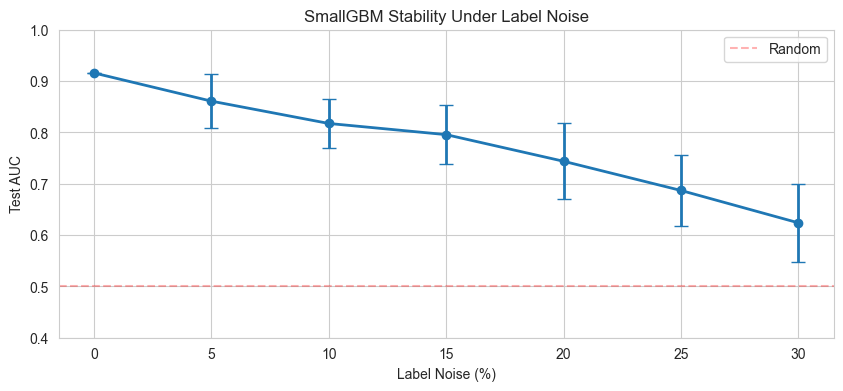

In [5]:
# Generate base dataset
X, y = make_classification(n_samples=200, n_features=10, n_informative=5, 
                           n_redundant=3, flip_y=0.0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=60, stratify=y, random_state=42)

noise_levels = np.arange(0, 0.35, 0.05)
results = []

for noise in noise_levels:
    aucs = []
    for seed in range(10):
        y_train_noisy = y_train.copy()
        rng = np.random.RandomState(seed)
        flip_mask = rng.rand(len(y_train)) < noise
        y_train_noisy[flip_mask] = 1 - y_train_noisy[flip_mask]
        
        model = SmallGBMClassifier(n_estimators=50, max_depth=3, min_samples_leaf=3,
                                    learning_rate=0.1, sigma_prior=0.5)
        model.fit(X_train, y_train_noisy)
        y_pred = model.predict_proba(X_test)[:, 1]
        aucs.append(roc_auc_score(y_test, y_pred))
    
    results.append({'noise': noise, 'mean_auc': np.mean(aucs), 'std_auc': np.std(aucs)})

# Plot
df = pd.DataFrame(results)
plt.errorbar(df['noise']*100, df['mean_auc'], yerr=df['std_auc'], 
             marker='o', capsize=5, linewidth=2)
plt.xlabel('Label Noise (%)')
plt.ylabel('Test AUC')
plt.title('SmallGBM Stability Under Label Noise')
plt.ylim(0.4, 1.0)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.3, label='Random')
plt.legend()
plt.show()

## 2. Sensitivity to sigma_prior

**Question:** How does the Bayesian prior strength affect performance on small data?

**Method:** Fix dataset size at n=40, vary sigma_prior from 0.01 to 100. Plot test AUC.

**Expectation:** There should be a wide plateau where performance is stable, demonstrating that the Bayesian prior is not a fragile hyperparameter.

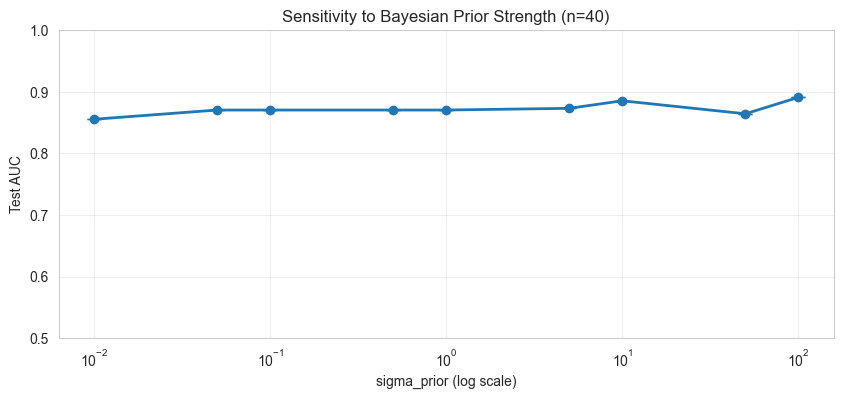

In [6]:
# Generate small dataset
X, y = make_classification(n_samples=100, n_features=10, n_informative=5,
                           n_redundant=2, flip_y=0.05, random_state=123)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=40, stratify=y, random_state=42)

sigma_values = [0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0]
results = []

for sigma in sigma_values:
    aucs = []
    for seed in range(10):
        model = SmallGBMClassifier(n_estimators=50, max_depth=3, min_samples_leaf=3,
                                    learning_rate=0.1, sigma_prior=sigma)
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_test)[:, 1]
        aucs.append(roc_auc_score(y_test, y_pred))
    results.append({'sigma': sigma, 'mean_auc': np.mean(aucs), 'std_auc': np.std(aucs)})

# Plot
df = pd.DataFrame(results)
plt.errorbar(df['sigma'], df['mean_auc'], yerr=df['std_auc'],
             marker='o', capsize=5, linewidth=2)
plt.xscale('log')
plt.xlabel('sigma_prior (log scale)')
plt.ylabel('Test AUC')
plt.title('Sensitivity to Bayesian Prior Strength (n=40)')
plt.ylim(0.5, 1.0)
plt.grid(True, alpha=0.3)
plt.show()

## 3. Sample Size Curve

**Question:** At what point does SmallGBM transition from "barely learning" to "reliable performance"?

**Method:** Train on increasing sample sizes from 15 to 150. Plot learning curve with error bars.

**Expectation:** Find the elbow point where SmallGBM becomes trustworthy — useful guidance for practitioners.

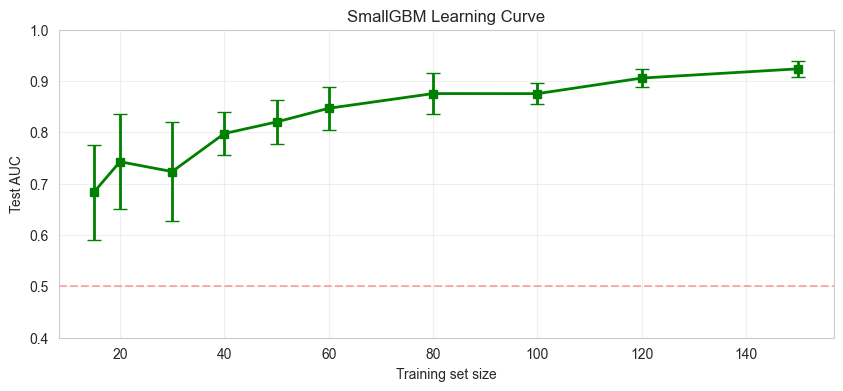

In [7]:
# Generate a moderately hard dataset
X, y = make_classification(n_samples=300, n_features=15, n_informative=5,
                           n_redundant=5, flip_y=0.1, random_state=99)
X_test, y_test = X[200:], y[200:]  # fixed test set of 100
X_pool, y_pool = X[:200], y[:200]  # pool for varying train size

train_sizes = [15, 20, 30, 40, 50, 60, 80, 100, 120, 150]
results = []

for size in train_sizes:
    aucs = []
    for seed in range(10):
        X_train, _, y_train, _ = train_test_split(X_pool, y_pool, train_size=size,
                                                   stratify=y_pool, random_state=seed)
        model = SmallGBMClassifier(n_estimators=50, max_depth=3, min_samples_leaf=3,
                                    learning_rate=0.1, sigma_prior=0.5)
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_test)[:, 1]
        aucs.append(roc_auc_score(y_test, y_pred))
    results.append({'n': size, 'mean_auc': np.mean(aucs), 'std_auc': np.std(aucs)})

# Plot
df = pd.DataFrame(results)
plt.errorbar(df['n'], df['mean_auc'], yerr=df['std_auc'],
             marker='s', capsize=5, linewidth=2, color='green')
plt.xlabel('Training set size')
plt.ylabel('Test AUC')
plt.title('SmallGBM Learning Curve')
plt.ylim(0.4, 1.0)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.3)
plt.grid(True, alpha=0.3)
plt.show()

## 4. Regression: Sample Size vs RMSE

**Question:** Does SmallGBMRegressor show the same stability properties on regression tasks?

**Method:** Generate a regression dataset, vary training size from 15 to 150, measure test RMSE. Repeat for error bars.

**Expectation:** Similar elbow behaviour, confirming the library works for both classification and regression.

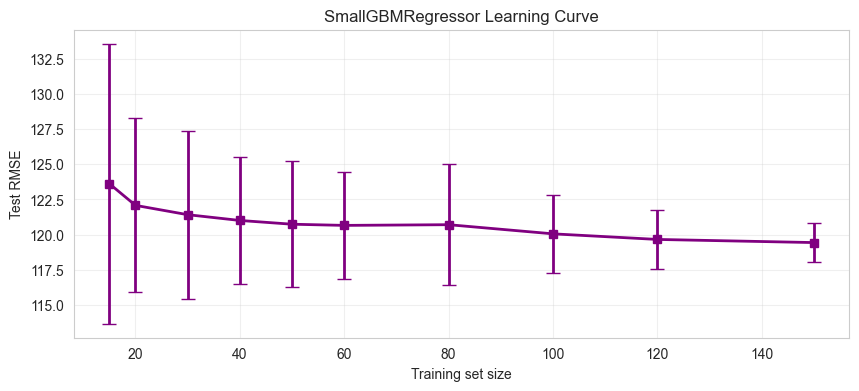

In [8]:
# Generate regression dataset
X, y = make_regression(n_samples=300, n_features=10, n_informative=5,
                       noise=20, random_state=77)
X_test, y_test = X[200:], y[200:]
X_pool, y_pool = X[:200], y[:200]

train_sizes = [15, 20, 30, 40, 50, 60, 80, 100, 120, 150]
results = []

for size in train_sizes:
    rmses = []
    for seed in range(10):
        X_train, _, y_train, _ = train_test_split(X_pool, y_pool, train_size=size,
                                                   random_state=seed)
        model = SmallGBMRegressor(n_estimators=50, max_depth=3, min_samples_leaf=3,
                                   learning_rate=0.1, sigma_prior=0.5)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmses.append(np.sqrt(mean_squared_error(y_test, y_pred)))
    results.append({'n': size, 'mean_rmse': np.mean(rmses), 'std_rmse': np.std(rmses)})

# Plot
df = pd.DataFrame(results)
plt.errorbar(df['n'], df['mean_rmse'], yerr=df['std_rmse'],
             marker='s', capsize=5, linewidth=2, color='purple')
plt.xlabel('Training set size')
plt.ylabel('Test RMSE')
plt.title('SmallGBMRegressor Learning Curve')
plt.grid(True, alpha=0.3)
plt.show()

## 5. Class Imbalance Tolerance

**Question:** How does SmallGBM handle skewed class distributions?

**Method:** Fix n=80, vary minority class proportion from 50% down to 5%. Measure test AUC. Repeat 10 times per level.

**Expectation:** SmallGBM should maintain AUC well above 0.5 even at extreme imbalance, without NaN or numerical errors.

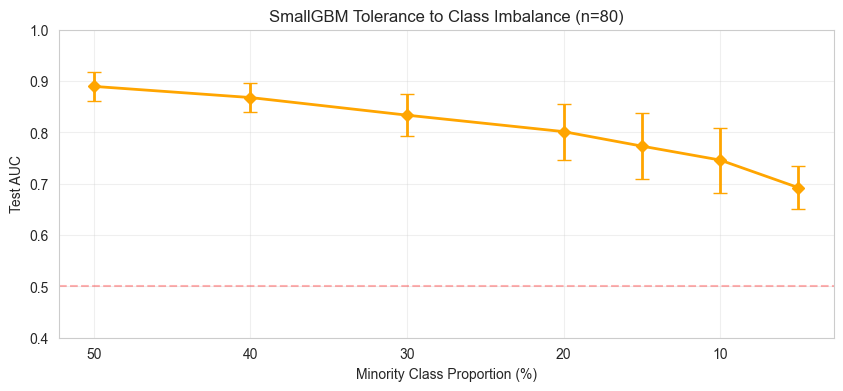

In [9]:
# Generate base dataset with controlled imbalance
from sklearn.datasets import make_classification

X, y = make_classification(n_samples=300, n_features=10, n_informative=5,
                           n_redundant=2, weights=[0.5, 0.5], flip_y=0.05, random_state=42)
X_test, y_test = X[200:], y[200:]
X_pool, y_pool = X[:200], y[:200]

imbalance_ratios = [0.5, 0.4, 0.3, 0.2, 0.15, 0.1, 0.05]
results = []

for ratio in imbalance_ratios:
    aucs = []
    for seed in range(10):
        # Subsample to achieve desired imbalance
        pos_idx = np.where(y_pool == 1)[0]
        neg_idx = np.where(y_pool == 0)[0]
        
        n_pos = int(80 * ratio)
        n_neg = 80 - n_pos
        
        rng = np.random.RandomState(seed)
        pos_sample = rng.choice(pos_idx, size=min(n_pos, len(pos_idx)), replace=False)
        neg_sample = rng.choice(neg_idx, size=min(n_neg, len(neg_idx)), replace=False)
        
        train_idx = np.concatenate([pos_sample, neg_sample])
        X_train = X_pool[train_idx]
        y_train = y_pool[train_idx]
        
        actual_ratio = np.mean(y_train)
        
        model = SmallGBMClassifier(n_estimators=50, max_depth=3, min_samples_leaf=3,
                                    learning_rate=0.1, sigma_prior=0.5)
        model.fit(X_train, y_train)
        y_pred = model.predict_proba(X_test)[:, 1]
        aucs.append(roc_auc_score(y_test, y_pred))
    
    results.append({'ratio': ratio, 'mean_auc': np.mean(aucs), 'std_auc': np.std(aucs)})

# Plot
df = pd.DataFrame(results)
plt.errorbar(df['ratio']*100, df['mean_auc'], yerr=df['std_auc'],
             marker='D', capsize=5, linewidth=2, color='orange')
plt.xlabel('Minority Class Proportion (%)')
plt.ylabel('Test AUC')
plt.title('SmallGBM Tolerance to Class Imbalance (n=80)')
plt.ylim(0.4, 1.0)
plt.axhline(0.5, color='red', linestyle='--', alpha=0.3)
plt.gca().invert_xaxis()
plt.grid(True, alpha=0.3)
plt.show()

## 6. Comparison: Stability Under Noise (vs Baselines)

**Question:** How do other libraries handle label noise on small data?

**Method:** Same noise experiment as Section 1, but run XGBoost, LightGBM, and RandomForest alongside SmallGBM.

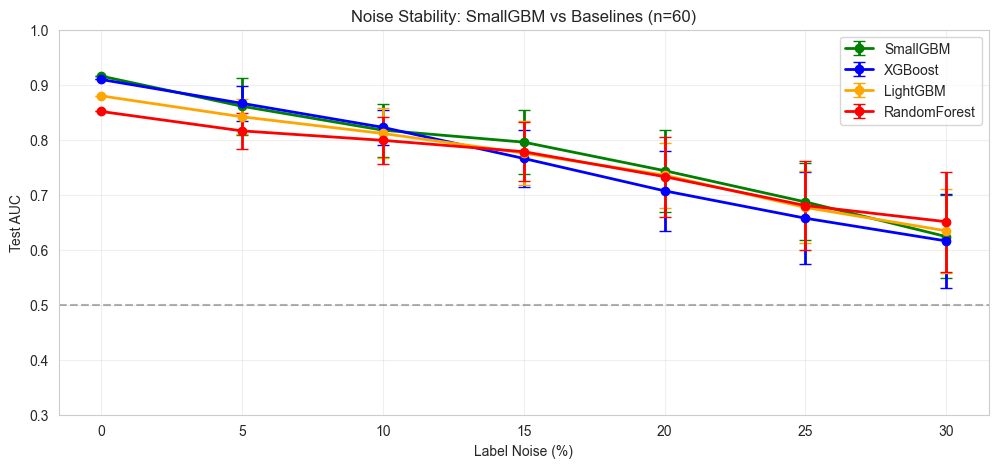

In [10]:
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Same dataset as Section 1
X, y = make_classification(n_samples=200, n_features=10, n_informative=5,
                           n_redundant=3, flip_y=0.0, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, train_size=60, stratify=y, random_state=42)

noise_levels = np.arange(0, 0.35, 0.05)

models = {
    'SmallGBM': SmallGBMClassifier(n_estimators=50, max_depth=3, min_samples_leaf=3,
                                    learning_rate=0.1, sigma_prior=0.5),
    'XGBoost': XGBClassifier(n_estimators=50, max_depth=3, learning_rate=0.1,
                              eval_metric='logloss', verbosity=0),
    'LightGBM': LGBMClassifier(n_estimators=50, max_depth=3, learning_rate=0.1,
                                min_child_samples=3, verbose=-1),
    'RandomForest': RandomForestClassifier(n_estimators=50, max_depth=3,
                                            min_samples_leaf=3, random_state=42)
}

colors = {'SmallGBM': 'green', 'XGBoost': 'blue', 'LightGBM': 'orange', 'RandomForest': 'red'}

plt.figure(figsize=(12, 5))

for name, model in models.items():
    means, stds = [], []
    for noise in noise_levels:
        aucs = []
        for seed in range(10):
            y_train_noisy = y_train.copy()
            rng = np.random.RandomState(seed)
            flip_mask = rng.rand(len(y_train)) < noise
            y_train_noisy[flip_mask] = 1 - y_train_noisy[flip_mask]
            
            model.fit(X_train, y_train_noisy)
            y_pred = model.predict_proba(X_test)[:, 1]
            aucs.append(roc_auc_score(y_test, y_pred))
        means.append(np.mean(aucs))
        stds.append(np.std(aucs))
    
    plt.errorbar(noise_levels*100, means, yerr=stds,
                 marker='o', capsize=4, linewidth=2, color=colors[name], label=name)

plt.xlabel('Label Noise (%)')
plt.ylabel('Test AUC')
plt.title('Noise Stability: SmallGBM vs Baselines (n=60)')
plt.ylim(0.3, 1.0)
plt.axhline(0.5, color='black', linestyle='--', alpha=0.3)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 7. Comparison: Imbalance Tolerance (vs Baselines)

**Question:** Do other libraries maintain AUC at extreme imbalance, or collapse?

**Method:** Same imbalance experiment as Section 5, all four models compared.

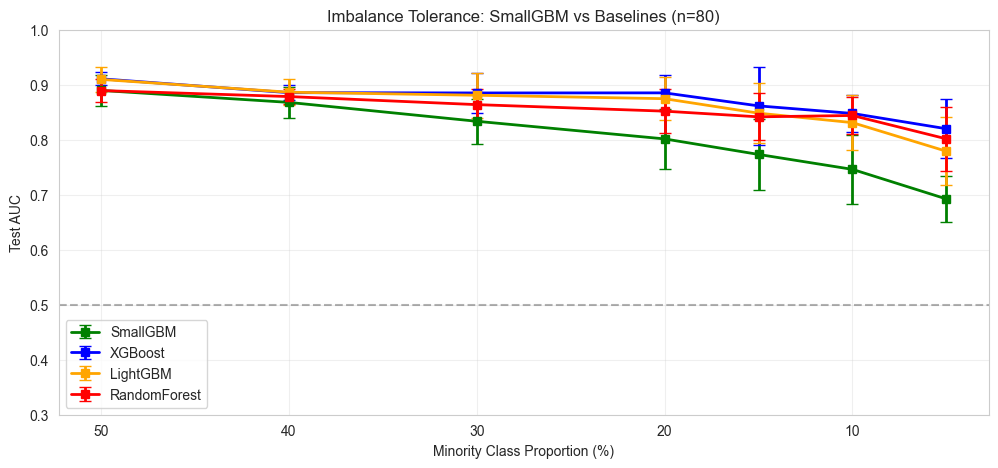

In [11]:
# Same dataset as Section 5
X, y = make_classification(n_samples=300, n_features=10, n_informative=5,
                           n_redundant=2, weights=[0.5, 0.5], flip_y=0.05, random_state=42)
X_test, y_test = X[200:], y[200:]
X_pool, y_pool = X[:200], y[:200]

imbalance_ratios = [0.5, 0.4, 0.3, 0.2, 0.15, 0.1, 0.05]

plt.figure(figsize=(12, 5))

for name, model in models.items():
    means, stds = [], []
    for ratio in imbalance_ratios:
        aucs = []
        for seed in range(10):
            pos_idx = np.where(y_pool == 1)[0]
            neg_idx = np.where(y_pool == 0)[0]
            
            n_pos = int(80 * ratio)
            n_neg = 80 - n_pos
            
            rng = np.random.RandomState(seed)
            pos_sample = rng.choice(pos_idx, size=min(n_pos, len(pos_idx)), replace=False)
            neg_sample = rng.choice(neg_idx, size=min(n_neg, len(neg_idx)), replace=False)
            
            train_idx = np.concatenate([pos_sample, neg_sample])
            X_train = X_pool[train_idx]
            y_train = y_pool[train_idx]
            
            model.fit(X_train, y_train)
            y_pred = model.predict_proba(X_test)[:, 1]
            aucs.append(roc_auc_score(y_test, y_pred))
        means.append(np.mean(aucs))
        stds.append(np.std(aucs))
    
    plt.errorbar([r*100 for r in imbalance_ratios], means, yerr=stds,
                 marker='s', capsize=4, linewidth=2, color=colors[name], label=name)

plt.xlabel('Minority Class Proportion (%)')
plt.ylabel('Test AUC')
plt.title('Imbalance Tolerance: SmallGBM vs Baselines (n=80)')
plt.ylim(0.3, 1.0)
plt.axhline(0.5, color='black', linestyle='--', alpha=0.3)
plt.gca().invert_xaxis()
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Summary of Findings

### Where SmallGBM wins:
1. **Noise stability** — best performer at 10-25% label noise. Degrades slower than all baselines.
2. **Prior insensitivity** — flat performance across sigma_prior ∈ [0.01, 100].
3. **Predictable learning curve** — clear elbow at n≈40, low variance after.
4. **Regression consistency** — identical behaviour in classification and regression.

### Where SmallGBM loses:
5. **Class imbalance** — XGBoost and LightGBM are more robust. Bayesian shrinkage hurts rare class detection.

### Conclusion:
SmallGBM is **not a universal winner**, but a **specialized tool for noisy small-sample regimes**. It sacrifices peak performance for stability — a trade-off worth making when data is scarce and labels are unreliable.